<a href="https://colab.research.google.com/github/ruilili3-cell/cs5494_tutorial/blob/main/cs5494_tutorial_1_MNIST.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

This tutorial has two parts. First, we download and inspect the MNIST handwritten-digit dataset. Then, we build a LeNet model and train and test it on MNIST. This example shows the complete PyTorch workflow for a basic image-classification task.

## MNIST Dataset

- download in colab
- show some images from the dataset

## LeNet (to step further)

- train LeNet from scratch based on MNIST
- test LeNet on MNIST

---

Here, we import PyTorch, `torchvision`, and the libraries needed for visualization. PyTorch is used to build and train the neural network, while `torchvision` provides the MNIST dataset.

In [ ]:
# 1. Import necessary libraries
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np

Then, we set the training parameters. The model processes 64 images at a time, uses the complete training set twice, and uses a learning rate of 0.001. `DEVICE` selects CUDA when a GPU is available and otherwise uses the CPU.

In [ ]:
# 2. Configure basic parameters (adjust as needed)
BATCH_SIZE = 64        # Batch size for training
EPOCHS = 2             # Number of training epochs
LEARNING_RATE = 0.001  # Learning rate for optimizer
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")  # Use GPU if available
print(f"Using device: {DEVICE}")

Using device: cuda


When an image is loaded, we first convert it into a PyTorch tensor and then normalize it using the MNIST mean of 0.1307 and standard deviation of 0.3081. MNIST contains single-channel grayscale images, so each tuple contains only one value.

We download the training and test sets and apply the preprocessing operations. MNIST contains 60,000 training images and 10,000 test images. Each image is a 28-by-28 handwritten digit.

`DataLoader` organizes the data into batches. The training data are shuffled, while the test data remain in their original order. A typical training batch has the shape 64 by 1 by 28 by 28, representing the number of images, channels, height, and width.

In [ ]:
# 3. Download MNIST dataset and create data loaders
# Data preprocessing: convert to Tensor and normalize (standard MNIST stats)
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))  # Mean and std for MNIST
])

# Download training set (train=True) and test set (train=False)
train_dataset = datasets.MNIST(
    root='./data',
    train=True,
    download=True,  # Automatically download if not exists
    transform=transform
)

test_dataset = datasets.MNIST(
    root='./data',
    train=False,
    download=True,
    transform=transform
)

# Create data loaders with batching and shuffling
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

100%|██████████| 9.91M/9.91M [00:00<00:00, 18.4MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 485kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.57MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 15.0MB/s]


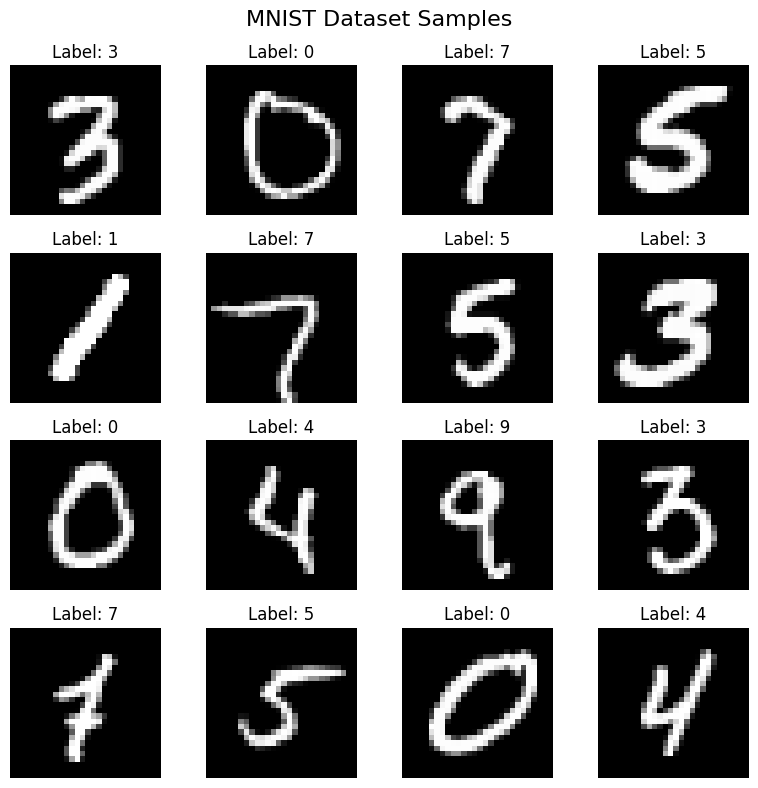

In [ ]:
# 4. Visualize sample images from MNIST dataset (16 random training samples)
def visualize_mnist_samples(dataset, num_samples=16):
    # Randomly select sample indices
    indices = np.random.choice(len(dataset), num_samples, replace=False)
    # Create 4x4 subplot layout
    fig, axes = plt.subplots(4, 4, figsize=(8, 8))
    fig.suptitle("MNIST Dataset Samples", fontsize=16)

    for i, idx in enumerate(indices):
        # Get image and label for the selected index
        img, label = dataset[idx]
        # Adjust dimensions: (1,28,28) -> (28,28) for visualization
        img = img.squeeze(0).numpy()
        # Denormalize to restore original brightness
        img = img * 0.3081 + 0.1307

        # Position in subplot grid
        row = i // 4
        col = i % 4
        axes[row, col].imshow(img, cmap='gray')  # Grayscale display
        axes[row, col].set_title(f"Label: {label}")  # Show true label
        axes[row, col].axis('off')  # Hide axis

    plt.tight_layout()
    plt.show()

# Call visualization function
visualize_mnist_samples(train_dataset)

We now define LeNet. The `__init__` method declares the layers, and the `forward` method specifies the order in which data passes through them.

The first convolution converts one grayscale channel into six feature maps. A 28-by-28 input becomes 24 by 24 after the five-by-five convolution and then 12 by 12 after pooling.

The second convolution converts six channels into sixteen. The spatial size changes from 12 to 8 and then to 4 after pooling. Therefore, the convolutional part produces sixteen four-by-four feature maps.

The convolutional output contains sixteen times four times four, or 256, features. The three fully connected layers change the feature dimension to 120, 84, and finally 10. The ten outputs correspond to digits zero through nine. ReLU introduces nonlinearity into the model.

In the forward pass, the input goes through convolution, ReLU, and pooling twice. `view` then flattens each example into a vector of length 256 before it enters the three fully connected layers.

The final result contains ten logits, or ten class scores. We do not apply Softmax here because the later `CrossEntropyLoss` works directly with these logits.

In [ ]:
# 5. Define LeNet-5 model (adapted for MNIST handwritten digit recognition)
class LeNet(nn.Module):
    def __init__(self):
        super(LeNet, self).__init__()
        # Convolutional layer 1: extract basic features (1->6 channels)
        self.conv1 = nn.Conv2d(1, 6, kernel_size=5, stride=1, padding=0)
        # Pooling layer: reduce spatial dimensions (average pooling)
        self.pool = nn.AvgPool2d(kernel_size=2, stride=2)
        # Convolutional layer 2: extract complex features (6->16 channels)
        self.conv2 = nn.Conv2d(6, 16, kernel_size=5, stride=1, padding=0)
        # Fully connected layer 1: flatten features (16*4*4 -> 120)
        self.fc1 = nn.Linear(16 * 4 * 4, 120)
        # Fully connected layer 2: reduce dimension (120 -> 84)
        self.fc2 = nn.Linear(120, 84)
        # Output layer: 10 classes for digits 0-9
        self.fc3 = nn.Linear(84, 10)
        # Activation function (ReLU for better training stability)
        self.relu = nn.ReLU()

    def forward(self, x):
        # Forward propagation: conv -> activation -> pooling
        x = self.pool(self.relu(self.conv1(x)))  # Output shape: (batch,6,12,12)
        x = self.pool(self.relu(self.conv2(x)))  # Output shape: (batch,16,4,4)
        # Flatten feature maps for fully connected layers
        x = x.view(-1, 16 * 4 * 4)
        # Pass through fully connected layers with activation
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        # Final output (no activation, CrossEntropyLoss includes Softmax)
        x = self.fc3(x)
        return x

# Initialize model and move to device (GPU/CPU)
model = LeNet().to(DEVICE)
print("\nLeNet model architecture:")
print(model)


LeNet model architecture:
LeNet(
  (conv1): Conv2d(1, 6, kernel_size=(5, 5), stride=(1, 1))
  (pool): AvgPool2d(kernel_size=2, stride=2, padding=0)
  (conv2): Conv2d(6, 16, kernel_size=(5, 5), stride=(1, 1))
  (fc1): Linear(in_features=256, out_features=120, bias=True)
  (fc2): Linear(in_features=120, out_features=84, bias=True)
  (fc3): Linear(in_features=84, out_features=10, bias=True)
  (relu): ReLU()
)


Cross-entropy measures the classification error, and Adam updates the model parameters using the gradients calculated from that error.

In [ ]:
# 6. Define loss function and optimizer
criterion = nn.CrossEntropyLoss()  # Suitable for multi-class classification
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)  # Adam optimizer for faster convergence

The training function performs one complete epoch. It reads each batch and moves the images and labels to the same device as the model.

These are the five core training steps: clear the previous gradients, perform a forward pass, calculate the loss, use backpropagation to calculate gradients, and update the parameters. The same operations are repeated for every batch.

For each image, we select the class with the highest of the ten output scores and count the correct predictions.

In [ ]:
# 7. Training function
def train(model, train_loader, criterion, optimizer, epoch):
    model.train()  # Set model to training mode (enable dropout etc.)
    total_loss = 0.0
    correct = 0
    total = 0

    for batch_idx, (data, target) in enumerate(train_loader):
        # Move data to target device
        data, target = data.to(DEVICE), target.to(DEVICE)

        # Reset gradients
        optimizer.zero_grad()
        # Forward pass: get model predictions
        output = model(data)
        # Calculate loss
        loss = criterion(output, target)
        # Backward pass: compute gradients
        loss.backward()
        # Update model parameters
        optimizer.step()

        # Accumulate training metrics
        total_loss += loss.item() * data.size(0)
        _, predicted = torch.max(output.data, 1)  # Get predicted class
        total += target.size(0)
        correct += (predicted == target).sum().item()  # Count correct predictions

        # Print progress every 100 batches
        if batch_idx % 100 == 0:
            print(f"Epoch [{epoch+1}/{EPOCHS}], Batch [{batch_idx+1}/{len(train_loader)}], "
                  f"Loss: {loss.item():.4f}, Acc: {100.*correct/total:.2f}%")

    # Calculate epoch-level metrics
    avg_loss = total_loss / len(train_loader.dataset)
    train_acc = 100. * correct / total
    print(f"\nEpoch [{epoch+1}/{EPOCHS}] Training Complete | Avg Loss: {avg_loss:.4f} | Training Accuracy: {train_acc:.2f}%")

The testing function is similar to the training function, but `eval` switches the model to evaluation mode and `no_grad` disables gradient calculation. Testing only makes predictions and records metrics. It performs no backpropagation and does not update the parameters.

Finally, the program prints the average test loss and accuracy.

In [ ]:
# 8. Testing function (evaluate generalization performance)
def test(model, test_loader, criterion):
    model.eval()  # Set model to evaluation mode (disable dropout etc.)
    test_loss = 0.0
    correct = 0
    total = 0

    # Disable gradient calculation for efficiency
    with torch.no_grad():
        for data, target in test_loader:
            data, target = data.to(DEVICE), target.to(DEVICE)
            output = model(data)
            # Accumulate test loss
            test_loss += criterion(output, target).item() * data.size(0)
            # Count correct predictions
            _, predicted = torch.max(output.data, 1)
            total += target.size(0)
            correct += (predicted == target).sum().item()

    # Calculate test set metrics
    avg_loss = test_loss / len(test_loader.dataset)
    test_acc = 100. * correct / total
    print(f"Test Set Results | Avg Loss: {avg_loss:.4f} | Test Accuracy: {test_acc:.2f}%\n")
    return test_acc

Finally, the program runs for two epochs. Each epoch performs training first and testing second, while recording the highest test accuracy.

In [ ]:
# 9. Start training and evaluation (main workflow)
print("\nStarting LeNet model training...")
best_test_acc = 0.0  # Track the best test accuracy

for epoch in range(EPOCHS):
    # Train for one epoch
    train(model, train_loader, criterion, optimizer, epoch)
    # Evaluate on test set
    current_test_acc = test(model, test_loader, criterion)
    # Update best accuracy if current is better
    if current_test_acc > best_test_acc:
        best_test_acc = current_test_acc

print(f"Training completed! Best test accuracy: {best_test_acc:.2f}%")


Starting LeNet model training...
Epoch [1/2], Batch [1/938], Loss: 2.3207, Acc: 4.69%
Epoch [1/2], Batch [101/938], Loss: 0.4588, Acc: 67.53%
Epoch [1/2], Batch [201/938], Loss: 0.5851, Acc: 77.93%
Epoch [1/2], Batch [301/938], Loss: 0.2968, Acc: 82.26%
Epoch [1/2], Batch [401/938], Loss: 0.1692, Acc: 84.80%
Epoch [1/2], Batch [501/938], Loss: 0.2032, Acc: 86.75%
Epoch [1/2], Batch [601/938], Loss: 0.2696, Acc: 88.15%
Epoch [1/2], Batch [701/938], Loss: 0.1683, Acc: 89.21%
Epoch [1/2], Batch [801/938], Loss: 0.0710, Acc: 90.02%
Epoch [1/2], Batch [901/938], Loss: 0.1038, Acc: 90.75%

Epoch [1/2] Training Complete | Avg Loss: 0.2994 | Training Accuracy: 91.00%
Test Set Results | Avg Loss: 0.0960 | Test Accuracy: 97.13%

Epoch [2/2], Batch [1/938], Loss: 0.1225, Acc: 93.75%
Epoch [2/2], Batch [101/938], Loss: 0.0533, Acc: 96.69%
Epoch [2/2], Batch [201/938], Loss: 0.0777, Acc: 96.57%
Epoch [2/2], Batch [301/938], Loss: 0.0316, Acc: 96.80%
Epoch [2/2], Batch [401/938], Loss: 0.0286, Acc: